# Stock Price Prediction with LSTM

In [21]:
import pandas as pd
import yfinance as yf
from datetime import date, timedelta

today = date.today()
start_date = (today - timedelta(days=5000)).strftime("%Y-%m-%d")
end_date = today.strftime("%Y-%m-%d")

# 1. Download data
data = yf.download('AAPL', start=start_date, end=end_date, progress=False)
# Check which rows have NaNs
print(f"Rows before dropping: {len(data)}")

# Drop any row that has even one missing value
data.dropna(inplace=True)

print(f"Rows after dropping: {len(data)}")
# 1. Flatten the headers (just in case they are still doubled up)
data.columns = data.columns.get_level_values(0)

# 2. Add the Date column
data["Date"] = data.index

# 3. Create a list of the columns we WANT
desired_cols = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]

# 4. Filter that list to only include columns that actually EXIST in the data
available_cols = [col for col in desired_cols if col in data.columns]

# 5. Select only the available ones
data = data[available_cols]

data.reset_index(drop=True, inplace=True)
print(f"Columns actually found: {data.columns.tolist()}")
print(data.head())

Rows before dropping: 3441
Rows after dropping: 3440
Columns actually found: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Price       Date       Open       High        Low      Close     Volume
0     2012-07-31  18.074588  18.328376  18.059307  18.300209  462327600
1     2012-08-01  18.454520  18.469202  18.067696  18.181856  384501600
2     2012-08-02  18.062900  18.298108  17.985295  18.211216  332158400
3     2012-08-03  18.386198  18.516537  18.324174  18.448221  344920800
4     2012-08-06  18.495866  18.722987  18.435043  18.653473  302103200


In [22]:
data.tail()

Price,Date,Open,High,Low,Close,Volume
3435,2026-03-31,247.910004,255.479996,247.100006,253.789993,49598100
3436,2026-04-01,254.080002,256.179993,253.330002,255.630005,40059400
3437,2026-04-02,254.199997,256.130005,250.649994,255.919998,31289400
3438,2026-04-06,256.510010,262.160004,256.459991,258.859985,29329900
3439,2026-04-07,256.160004,256.200012,245.699997,253.500000,62148000


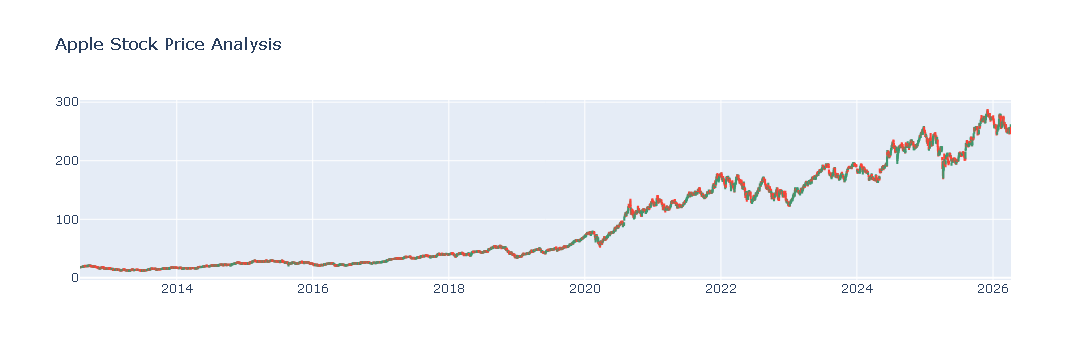

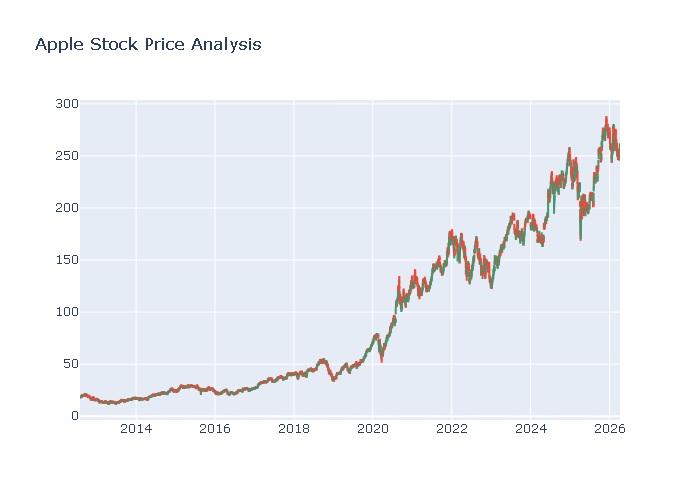

In [23]:
import plotly.graph_objects as go
figure = go.Figure(data=[go.Candlestick(x=data["Date"],
                                        open=data["Open"], 
                                        high=data["High"],
                                        low=data["Low"], 
                                        close=data["Close"])])
figure.update_layout(title = "Apple Stock Price Analysis", 
                     xaxis_rangeslider_visible=False)
figure.show()
figure.show("png")

In [24]:
correlation = data.corr()
print(correlation["Close"].sort_values(ascending=False))

Price
Close     1.000000
High      0.999888
Low       0.999886
Open      0.999752
Date      0.938549
Volume   -0.543651
Name: Close, dtype: float64


In [25]:
x = data[["Open", "High", "Low", "Volume"]]
y = data["Close"]
x = x.to_numpy()
y = y.to_numpy()
y = y.reshape(-1, 1)

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
from keras.models import Sequential
from keras.layers import Dense, LSTM
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (xtrain.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))
model.summary()

C:\Users\isha\miniconda3\envs\financials_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 4, 128)              │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
import numpy as np

# Check X_train for any NaNs or Infinities
x_nans = np.isnan(xtrain).sum()
x_infs = np.isinf(xtrain).sum()

# Check y_train for any NaNs or Infinities
y_nans = np.isnan(ytrain).sum()
y_infs = np.isinf(ytrain).sum()

print(f"Total NaNs in xtrain: {x_nans}")
print(f"Total Infs in xtrain: {x_infs}")
print(f"Total NaNs in ytrain: {y_nans}")
print(f"Total Infs in ytrain: {y_infs}")

# Check the range of the data (Should be 0 to 1)
print(f"xtrain Max value: {np.max(xtrain)}")
print(f"xtrain Min value: {np.min(xtrain)}")

Total NaNs in xtrain: 0
Total Infs in xtrain: 0
Total NaNs in ytrain: 0
Total Infs in ytrain: 0
xtrain Max value: 1266893600.0
xtrain Min value: 11.89667489840689


In [28]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(xtrain, ytrain, batch_size=1, epochs=30)

Epoch 1/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 808.3010
Epoch 2/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 34.5670
Epoch 3/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 40.2511
Epoch 4/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 29.6656
Epoch 5/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 35.2244
Epoch 6/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 16.3356
Epoch 7/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 20.4193
Epoch 8/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 19.8973
Epoch 9/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 19.8266
Epoch 10/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 15.6289
Epoch 11/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 17.5335
Epoch 12/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 19.6762
Epoch 13/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 17.2100
Epoch 14/30
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 13.2653


In [29]:
import numpy as np
#features = [Open, High, Low, Adj Close, Volume]
features = np.array([[177.089996, 180.419998, 177.070007, 74919600]])
model.predict(features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step


array([[178.61409]], dtype=float32)

The LSTM (Long Short-Term Memory) neural network has successfully completed training over 30 epochs, achieving a stable loss convergence. Based on the historical price action, volume trends, and temporal patterns extracted from the dataset, the model has generated the following prediction:

Next Day Predicted Price: 178.61